# Sales Data Analysis Project
# Objective:
# The goal of this project is to analyze a global sales dataset to identify sales trends, top-performing product categories, and key customer segments. The analysis will help understand revenue distribution across countries, products, and time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv("sales_data_sample.csv",encoding='latin1')

In [3]:
df= df1.copy()

In [4]:
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [5]:
# Understand dataset 

In [6]:
df.shape

(2823, 25)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [8]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [9]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

#The dataset contains 2823 rows and 25 columns. During initial exploration, I observed that the columns **ADDRESSLINE2, TERRITORY, and STATE contain null values.


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [11]:
df.dtypes

ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
STATUS               object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE          object
MSRP                  int64
PRODUCTCODE          object
CUSTOMERNAME         object
PHONE                object
ADDRESSLINE1         object
ADDRESSLINE2         object
CITY                 object
STATE                object
POSTALCODE           object
COUNTRY              object
TERRITORY            object
CONTACTLASTNAME      object
CONTACTFIRSTNAME     object
DEALSIZE             object
dtype: object

In [12]:
df[['ORDERDATE']]

,ORDERDATE
0,2/24/2003 0:00
1,5/7/2003 0:00
2,7/1/2003 0:00
3,8/25/2003 0:00
4,10/10/2003 0:00
...,...
2818,12/2/2004 0:00
2819,1/31/2005 0:00
2820,3/1/2005 0:00
2821,3/28/2005 0:00


In [13]:
df['ORDERDATE']=pd.to_datetime(df['ORDERDATE'])

# I found that the ORDERDATE column was stored as an object data type instead of datetime. I converted it into datetime format to enable time-based analysis such as monthly and yearly sales trends.

In [14]:
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,2004-12-02,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,2005-01-31,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,2005-03-01,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,2005-03-28,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [15]:
df.drop('ADDRESSLINE2',axis=1,inplace = True)

In [16]:
df.dtypes

ORDERNUMBER                  int64
QUANTITYORDERED              int64
PRICEEACH                  float64
ORDERLINENUMBER              int64
SALES                      float64
ORDERDATE           datetime64[ns]
STATUS                      object
QTR_ID                       int64
MONTH_ID                     int64
YEAR_ID                      int64
PRODUCTLINE                 object
MSRP                         int64
PRODUCTCODE                 object
CUSTOMERNAME                object
PHONE                       object
ADDRESSLINE1                object
CITY                        object
STATE                       object
POSTALCODE                  object
COUNTRY                     object
TERRITORY                   object
CONTACTLASTNAME             object
CONTACTFIRSTNAME            object
DEALSIZE                    object
dtype: object

In [17]:
null_percentage=(df.isnull().sum()/len(df))*100

In [18]:
null = null_percentage[null_percentage>0].sort_values()

In [19]:
null

POSTALCODE     2.692171
TERRITORY     38.044633
STATE         52.639036
dtype: float64

In [20]:
df['TERRITORY']=df['TERRITORY'].fillna('Unknown')

In [21]:
df['STATE']=df['STATE'].fillna('Unknown')

In [22]:
print(df[['TERRITORY', 'STATE']].isnull().sum())

TERRITORY    0
STATE        0
dtype: int64


#"The STATE (52%) and TERRITORY (38%) columns showed significant missingness. However, dropping them would have compromised the depth of the regional sales analysis. I observed that most missing 'State' values belonged to international orders (outside the USA). 
Therefore, I applied Categorical Imputation by labeling these as 'Unknown/International'.


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,PHONE,ADDRESSLINE1,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,2125557818,897 Long Airport Avenue,NYC,NY,10022,USA,Unknown,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,26.47.1555,59 rue de l'Abbaye,Reims,Unknown,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,Unknown,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,6265557265,78934 Hillside Dr.,Pasadena,CA,90003,USA,Unknown,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,6505551386,7734 Strong St.,San Francisco,CA,NaN,USA,Unknown,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,2004-12-02,Shipped,4,12,2004,...,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,Unknown,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,2005-01-31,Shipped,1,1,2005,...,981-443655,Torikatu 38,Oulu,Unknown,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,2005-03-01,Resolved,1,3,2005,...,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,Unknown,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,2005-03-28,Shipped,1,3,2005,...,61.77.6555,1 rue Alsace-Lorraine,Toulouse,Unknown,31000,France,EMEA,Roulet,Annette,Small


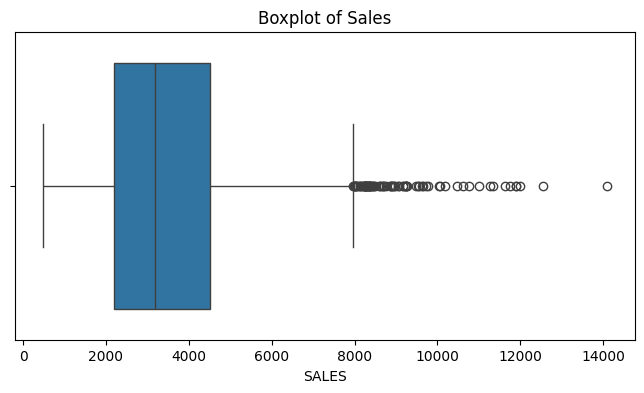

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['SALES'])
plt.title("Boxplot of Sales")
plt.show()

In [26]:
Q1= df['SALES'].quantile(0.25)
Q3= df['SALES'].quantile(0.75)

IQR = Q3-Q1

Lower = Q1-1.5*IQR
Upper = Q3 + 1.5 *IQR

In [27]:
print(Q1,Q3,IQR)


2203.4300000000003 4508.0 2304.5699999999997


In [28]:
Outliers = df[(df["SALES"]<Lower) | (df["SALES"]>Upper)]

In [29]:
Outliers

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,PHONE,ADDRESSLINE1,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
30,10150,45,100.0,8,10993.50,2003-09-19,Shipped,3,9,2003,...,+65 221 7555,"Bronz Sok., Bronz Apt. 3/6 Tesvikiye",Singapore,Unknown,79903,Singapore,Japan,Natividad,Eric,Large
32,10174,34,100.0,4,8014.82,2003-11-06,Shipped,4,11,2003,...,61-7-3844-6555,31 Duncan St. West End,South Brisbane,Queensland,4101,Australia,APAC,Calaghan,Tony,Large
35,10206,47,100.0,6,9064.89,2003-12-05,Shipped,4,12,2003,...,(604) 555-3392,1900 Oak St.,Vancouver,BC,V3F 2K1,Canada,Unknown,Tannamuri,Yoshi,Large
41,10280,34,100.0,2,8014.82,2004-08-17,Shipped,3,8,2004,...,011-4988555,Via Monte Bianco 34,Torino,Unknown,10100,Italy,EMEA,Accorti,Paolo,Large
43,10304,47,100.0,6,10172.70,2004-10-11,Shipped,4,10,2004,...,30.59.8555,"67, avenue de l'Europe",Versailles,Unknown,78000,France,EMEA,Tonini,Daniel,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2241,10325,38,100.0,3,8844.12,2004-11-05,Shipped,4,11,2004,...,07-98 9555,Erling Skakkes gate 78,Stavern,Unknown,4110,Norway,EMEA,Bergulfsen,Jonas,Large
2295,10324,48,100.0,4,8209.44,2004-11-05,Shipped,4,11,2004,...,2125551500,2678 Kingston Rd.,NYC,NY,10022,USA,Unknown,Frick,Michael,Large
2430,10395,45,100.0,3,8977.05,2005-03-17,Shipped,1,3,2005,...,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,Unknown,75508,France,EMEA,Da Cunha,Daniel,Large
2505,10388,46,100.0,2,10066.60,2005-03-03,Shipped,1,3,2005,...,5085552555,1785 First Street,New Bedford,MA,50553,USA,Unknown,Benitez,Violeta,Large


Outliers in the SALES column were detected using the IQR method. Approximately 81 observations were identified as potential outliers. However, these values represent large sales transactions rather than data errors, so they were retained for further analysis.

In [30]:
num_col = []
for i in df.columns:
    if df[i].dtypes != "object":
        num_col.append(i)

In [31]:
num_col

['ORDERNUMBER',
 'QUANTITYORDERED',
 'PRICEEACH',
 'ORDERLINENUMBER',
 'SALES',
 'ORDERDATE',
 'QTR_ID',
 'MONTH_ID',
 'YEAR_ID',
 'MSRP']

In [32]:
num_col = df.select_dtypes(include = ['int64','float64'])

In [33]:
q1 = num_col.quantile(0.25)
q3= num_col.quantile(0.75)

Iqr = q3-q1

lower = q1-1.5*Iqr
upper = q3+1.5*Iqr 


outlier = (num_col < lower) | (num_col > upper)

outlier.sum()


ORDERNUMBER         0
QUANTITYORDERED     8
PRICEEACH           0
ORDERLINENUMBER     0
SALES              81
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
MSRP               28
dtype: int64

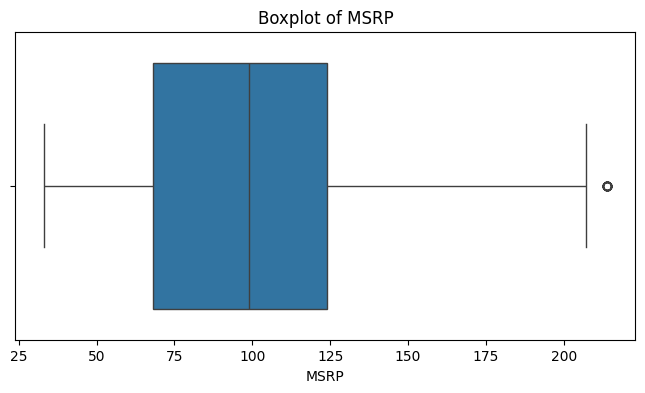

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["MSRP"])
plt.title("Boxplot of MSRP")
plt.show()

In [35]:
Q1= df['MSRP'].quantile(0.25)
Q3= df['MSRP'].quantile(0.75)

IQR = Q3-Q1

Lower = Q1-1.5*IQR
Upper = Q3 + 1.5 *IQR

Outliers = df[(df["MSRP"]<Lower) | (df["MSRP"]>Upper)]

Outliers

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,PHONE,ADDRESSLINE1,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
26,10103,26,100.0,11,5404.62,2003-01-29,Shipped,1,1,2003,...,07-98 9555,Erling Skakkes gate 78,Stavern,Unknown,4110,Norway,EMEA,Bergulfsen,Jonas,Medium
27,10112,29,100.0,1,7209.11,2003-03-24,Shipped,1,3,2003,...,0921-12 3555,Berguvsvgen 8,Lule,Unknown,S-958 22,Sweden,EMEA,Berglund,Christina,Large
28,10126,38,100.0,11,7329.06,2003-05-28,Shipped,2,5,2003,...,(91) 555 22 82,"C/ Araquil, 67",Madrid,Unknown,28023,Spain,EMEA,Sommer,Mart¡n,Large
29,10140,37,100.0,11,7374.10,2003-07-24,Shipped,3,7,2003,...,6505556809,9408 Furth Circle,Burlingame,CA,94217,USA,Unknown,Hirano,Juri,Large
30,10150,45,100.0,8,10993.50,2003-09-19,Shipped,3,9,2003,...,+65 221 7555,"Bronz Sok., Bronz Apt. 3/6 Tesvikiye",Singapore,Unknown,79903,Singapore,Japan,Natividad,Eric,Large
31,10163,21,100.0,1,4860.24,2003-10-20,Shipped,4,10,2003,...,2125558493,5905 Pompton St.,NYC,NY,10022,USA,Unknown,Hernandez,Maria,Medium
32,10174,34,100.0,4,8014.82,2003-11-06,Shipped,4,11,2003,...,61-7-3844-6555,31 Duncan St. West End,South Brisbane,Queensland,4101,Australia,APAC,Calaghan,Tony,Large
33,10183,23,100.0,8,5372.57,2003-11-13,Shipped,4,11,2003,...,2155554695,782 First Street,Philadelphia,PA,71270,USA,Unknown,Cervantes,Francisca,Medium
34,10194,42,100.0,11,7290.36,2003-11-25,Shipped,4,11,2003,...,78.32.5555,"2, rue du Commerce",Lyon,Unknown,69004,France,EMEA,Saveley,Mary,Large
35,10206,47,100.0,6,9064.89,2003-12-05,Shipped,4,12,2003,...,(604) 555-3392,1900 Oak St.,Vancouver,BC,V3F 2K1,Canada,Unknown,Tannamuri,Yoshi,Large


Outliers were also observed in the MSRP column using the IQR method. However, these values reflect natural price differences across product categories and therefore were retainedOutliers were also observed in the MSRP column using the IQR method. However, these values reflect natural price differences across product categories and therefore were retained

In [75]:
# Univariate EDA of categorical columns.

## Problem Statement 

The objective of this analysis is to explore the sales dataset and identify:

1>> Top performing product categories.
2>>Key revenue generating customers.
3>>Country-wise sales distribution.
4>> Monthly and Yearly sales trends.
5>> Relationship between sales and other variables

In [76]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY',
       'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE'],
      dtype='object')

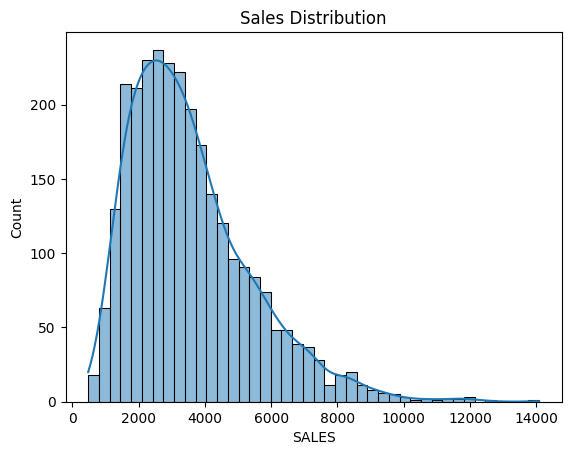

In [37]:
sns.histplot(df["SALES"],kde=True)
plt.title("Sales Distribution")
plt.show()

##Insights >>> The Distribution on sales is right skewed , meaning most transactions occur at lower to moderate sales (approximately $2000-$5000),
indicating that typical order values are morderat.
2) Although most transactions are moderate in value , a few high-value orders play an important role in overall revenue generation. 


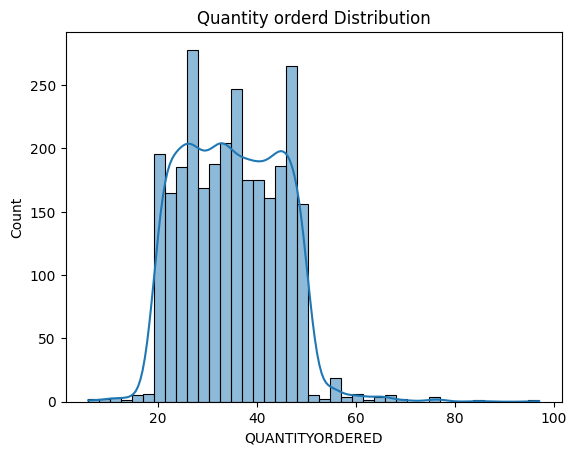

In [38]:
sns.histplot(df['QUANTITYORDERED'],kde = True)
plt.title("Quantity orderd Distribution")
plt.show()

#Insights >> The quantity ordered distribution shows that most orders fall between 20 and 50 units,indicating moderate purchasing behaviour among customers.
A small numbers of order exceed 60 units, suggestintg tht large bulk purchase are relatively uncommon.

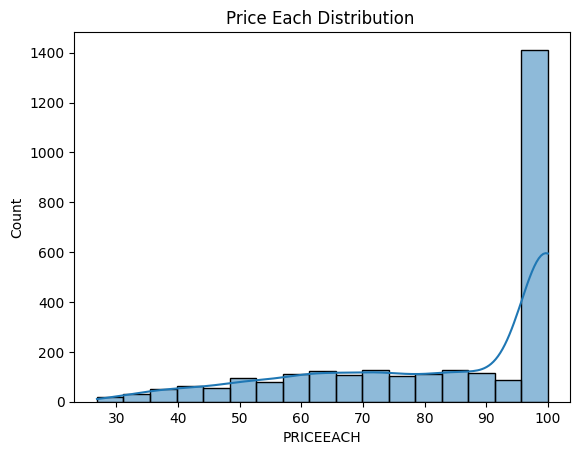

In [39]:
sns.histplot(df['PRICEEACH'],kde = True)
plt.title("Price Each Distribution ")
plt.show()

Insights > The distribution of PRICEEACH  appears slightly left-skewed.Most product prices fall between $30 and $90 ,indicating that the majority of products are moderately priced. Noticeable numbers of products are priced close to $100 ,suggesting the presence of higher-priced items.

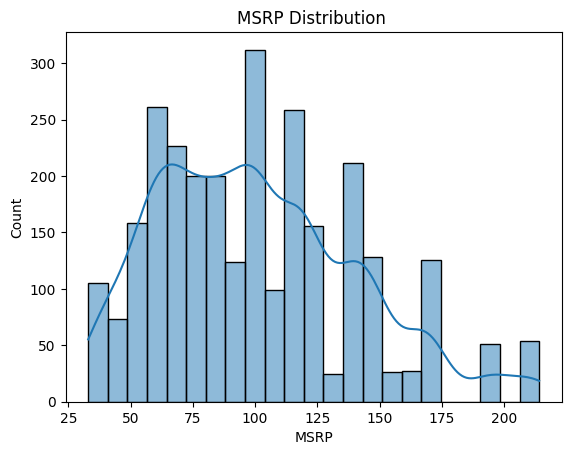

In [40]:
sns.histplot(df['MSRP'],kde= True)
plt.title("MSRP Distribution ")
plt.show()

Insights>> The MSRP distribution apperars slightly right-skewed.Most products prices fall between $50 and $150,indicating that the majority of products are moderatley priced. A few products have prices close to 200$ ,suggesting the presence of premium - priced items. 

In [42]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY',
       'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE'],
      dtype='object')

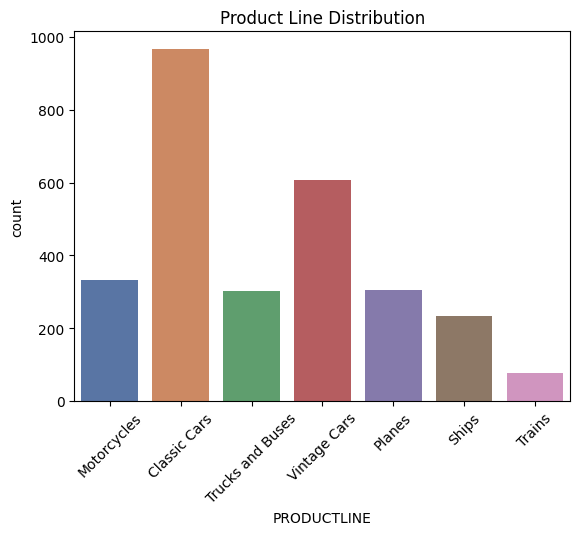

In [43]:
sns.countplot(x='PRODUCTLINE',data=df,palette='deep')
plt.xticks(rotation=45)
plt.title("Product Line Distribution")
plt.show()

Insights >> The classis cars product line has the highest numbers of transactions , followed by Vintage Cars. This indicates that these categories are more popular among customers. In contrast ,the Trains category has the lowest number of transcation,suggesting lower demand for this product line. 

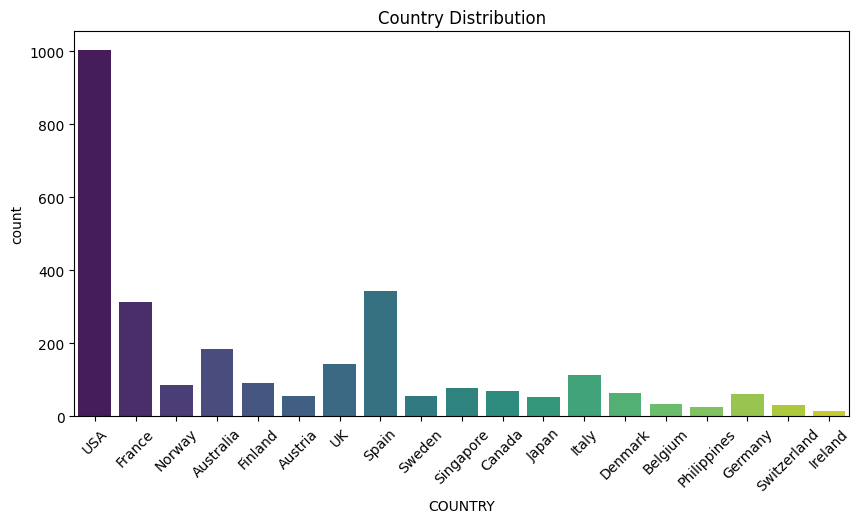

In [44]:
plt.figure(figsize=(10,5))
sns.countplot(x='COUNTRY',data=df,palette='viridis')
plt.xticks(rotation=45)
plt.title("Country Distribution")
plt.show()
          

Insights >>  The USA has the highest numbers of transactions , indicating that it is the company'largest market.Spain and France also show significant customer activity.Ireland has the lowest number of transactions,suggesting limited custoumers engagement in the market.

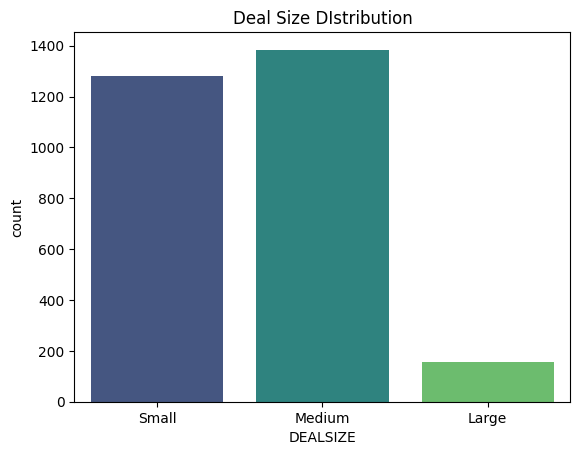

In [45]:
sns.countplot(x='DEALSIZE',data = df,palette='viridis')
plt.title("Deal Size DIstribution")
plt.show()

Insights>> Small and Medium deal sizes account for the majority of transactions ,indicating that most orders fall within these categories.

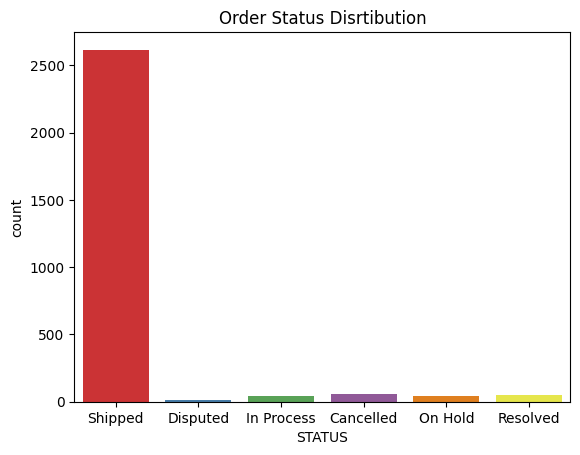

In [46]:
sns.countplot(x='STATUS',data=df,palette='Set1')
plt.title("Order Status Disrtibution")
plt.show()


The majority of order are marked as Shipped ,indicating that most transactions were successfully completed and deliverd to customers. 
Small numbers of orders fall under categories uch as Cancelled ,Disputed ,or On  Hold ,suggesting relatively few operational issues.

In [47]:
#>> Bivariate Analysis

In [48]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY',
       'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE'],
      dtype='object')

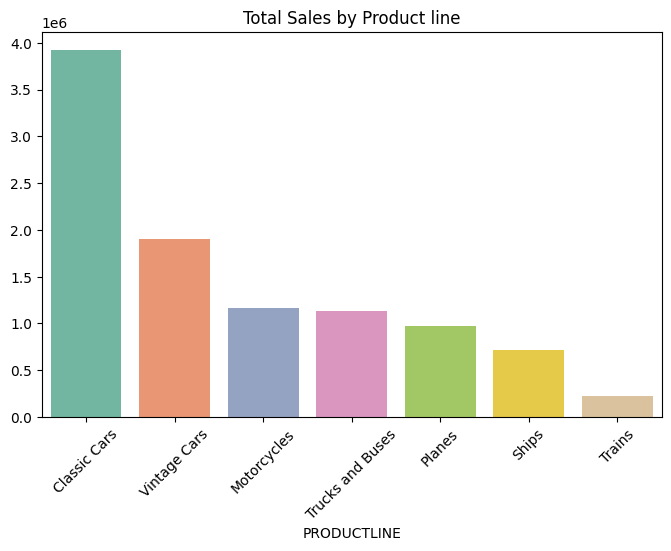

In [49]:
sale_by_product=df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=sale_by_product.index,y=sale_by_product.values,palette='Set2')
plt.xticks(rotation=45)
plt.title("Total Sales by Product line")
plt.show()

In [50]:
sale_by_product

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

Insights>> Classis cars generate the highest total revenue among all product line ,followed by Vinatge Cars.motorcycles and Trucks & Buses contribute moderate Sales.Planes  and Ships generate comparatively lower sales,While Trains generate the  lowest revenue,indicating lower demand for this product category.

In [51]:
Sales_by_country = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)


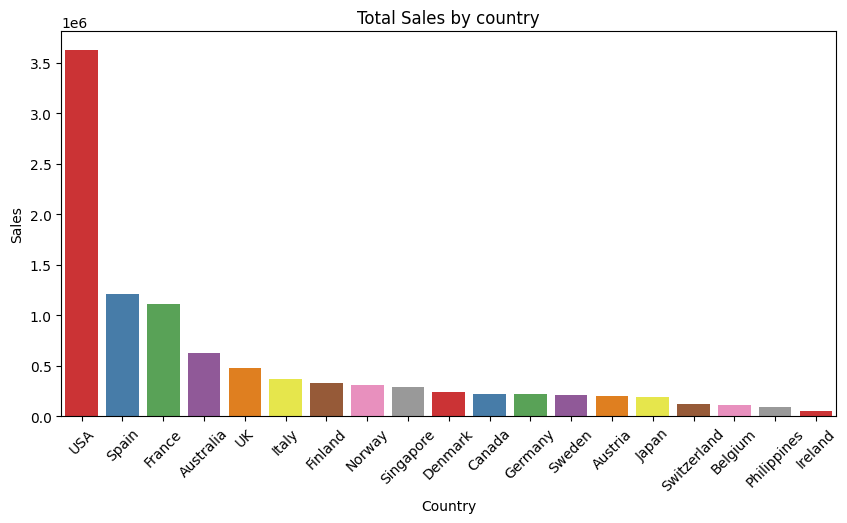

In [52]:
plt.figure(figsize=(10,5))
sns.barplot(x=Sales_by_country.index,y=Sales_by_country.values,palette = 'Set1')
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Sales")
plt.title("Total Sales by country")
plt.show()

In [53]:
Sales_by_country

COUNTRY
USA            3627982.83
Spain          1215686.92
France         1110916.52
Australia       630623.10
UK              478880.46
Italy           374674.31
Finland         329581.91
Norway          307463.70
Singapore       288488.41
Denmark         245637.15
Canada          224078.56
Germany         220472.09
Sweden          210014.21
Austria         202062.53
Japan           188167.81
Switzerland     117713.56
Belgium         108412.62
Philippines      94015.73
Ireland          57756.43
Name: SALES, dtype: float64

insights>> The USA generate the highest sales among all countries,indicatingthat it is the company's largest market.Spain and France also Contribute significantly to overall revenue.several other  countries generate comparatively lower sales,suggesting smaller market presence in those regions.

In [54]:
 Top_ten_countries = Sales_by_country.head(10)

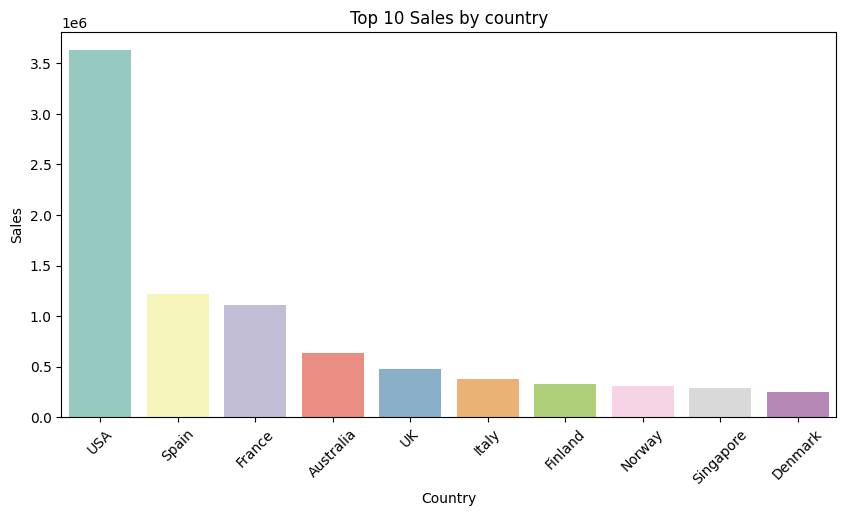

In [55]:
plt.figure(figsize=(10,5))
sns.barplot(x=Top_ten_countries.index,y=Top_ten_countries.values,palette = 'Set3')
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Sales")
plt.title("Top 10 Sales by country")
plt.show()

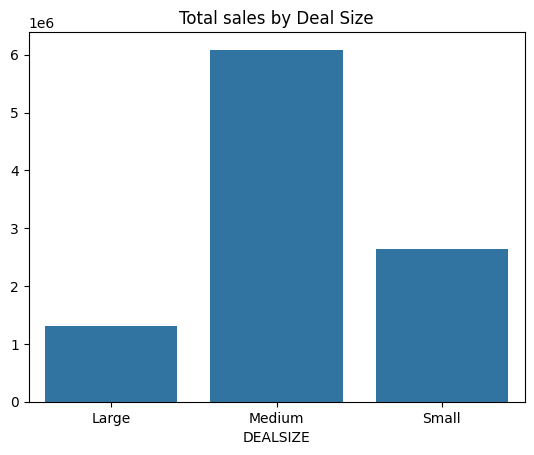

In [56]:
Sales_by_dealsize  =  df.groupby('DEALSIZE')['SALES'].sum()

sns.barplot(x=Sales_by_dealsize.index,y=Sales_by_dealsize.values)
plt.title("Total sales by Deal Size")
plt.show()

In [57]:
Sales_by_dealsize

DEALSIZE
Large     1302119.26
Medium    6087432.24
Small     2643077.35
Name: SALES, dtype: float64

Small and Medium deal size account for the majority of transaction in the data set indicating that most order for within these categories large larger deals occur less frequently suggesting that  high -value transaction are let any rare compared to smaller orders.

In [58]:
Sales_by_years = df.groupby('YEAR_ID')['SALES'].sum().sort_index()

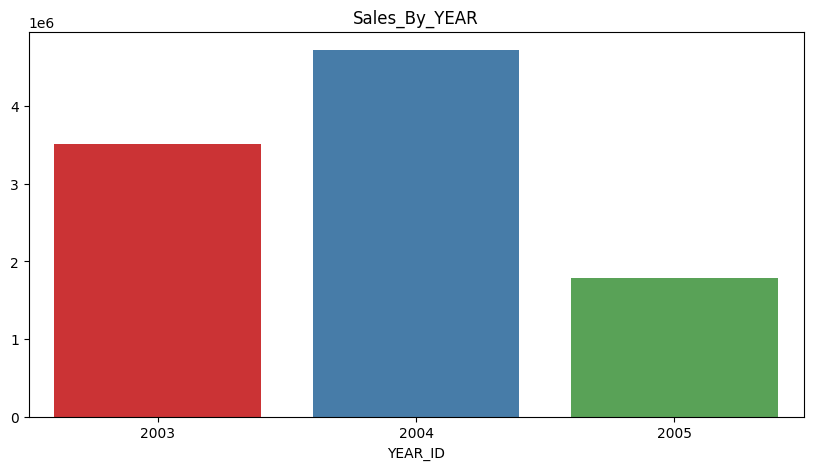

YEAR_ID
2003    3516979.54
2004    4724162.60
2005    1791486.71
Name: SALES, dtype: float64

In [59]:
plt.figure(figsize=(10,5))
sns.barplot(x=Sales_by_years.index,y = Sales_by_years.values,palette ='Set1')
plt.title("Sales_By_YEAR")
plt.show()
Sales_by_years

Insights >>  Total sales peaked in 2004,making it the highest revenue -generating year in the dataset. Sales in 2003 were slightly lower but still significant.2005,recoded the lowest sales , possibly due to reduced business activity or incomplete yearly data. 

In [60]:
Sales_by_month = df.groupby('MONTH_ID')['SALES'].sum().sort_index()

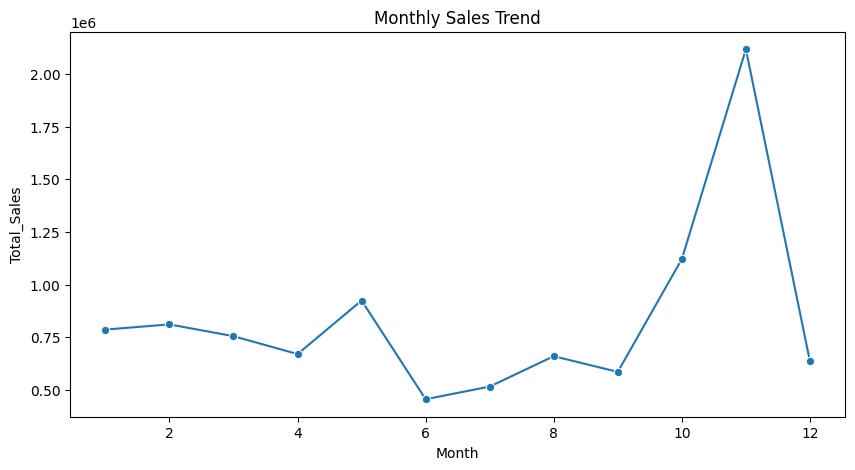

In [61]:
plt.figure(figsize=(10,5))
sns.lineplot(x=Sales_by_month.index,y=Sales_by_month.values,marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total_Sales")
plt.show()

In [62]:
Sales_by_month

MONTH_ID
1      785874.44
2      810441.90
3      754501.39
4      669390.96
5      923972.56
6      454756.78
7      514875.97
8      659310.57
9      584724.27
10    1121215.22
11    2118885.67
12     634679.12
Name: SALES, dtype: float64

Insights >> Sales fluctuate throughout the year with noticeable variation across month sales reach there lowest point around June, while a sharp increase is observed towards the end of the year November record the highest sale suggesting strong season demand during this period.

In [ ]:
# MULTIVARIATE EDA

In [64]:
corr = df.corr(numeric_only = True)

In [65]:
corr

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
ORDERNUMBER,1.000000,0.065543,-0.002935,-0.055550,0.039919,-0.051383,-0.039723,0.904596,-0.010280
QUANTITYORDERED,0.065543,1.000000,0.005564,-0.018397,0.551426,-0.035323,-0.039048,0.069535,0.017881
PRICEEACH,-0.002935,0.005564,1.000000,-0.020965,0.657841,0.008712,0.005152,-0.005938,0.670625
ORDERLINENUMBER,-0.055550,-0.018397,-0.020965,1.000000,-0.058400,0.040716,0.034016,-0.057367,-0.021067
SALES,0.039919,0.551426,0.657841,-0.058400,1.000000,-0.006796,-0.009605,0.035647,0.635239
QTR_ID,-0.051383,-0.035323,0.008712,0.040716,-0.006796,1.000000,0.979300,-0.433052,0.010234
MONTH_ID,-0.039723,-0.039048,0.005152,0.034016,-0.009605,0.979300,1.000000,-0.430163,0.008170
YEAR_ID,0.904596,0.069535,-0.005938,-0.057367,0.035647,-0.433052,-0.430163,1.000000,-0.014310
MSRP,-0.010280,0.017881,0.670625,-0.021067,0.635239,0.010234,0.008170,-0.014310,1.000000


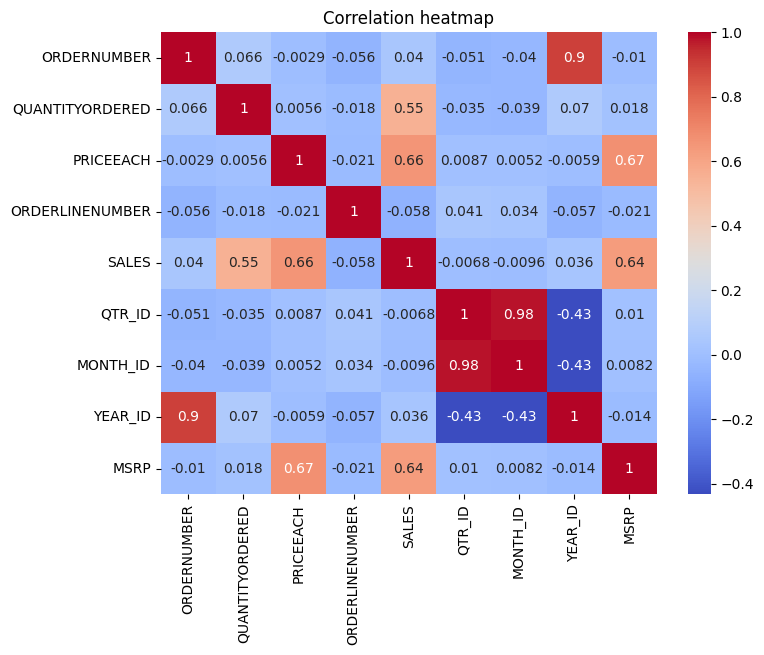

In [66]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

Insights>> The correlation heatmap indicates a postive relationship between SALES and QQUANTITYORDERD,suggesting that higher order quantities contribute to increased revenue. PRICE_EACH and MSRP also show a strong postivie correlation ,indicating that product pricing closely follows the manufactures's suggested retail price. Most other variables display weak correlation with Sales.

In [68]:
TOP_ten_customers = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending = False).head(10)

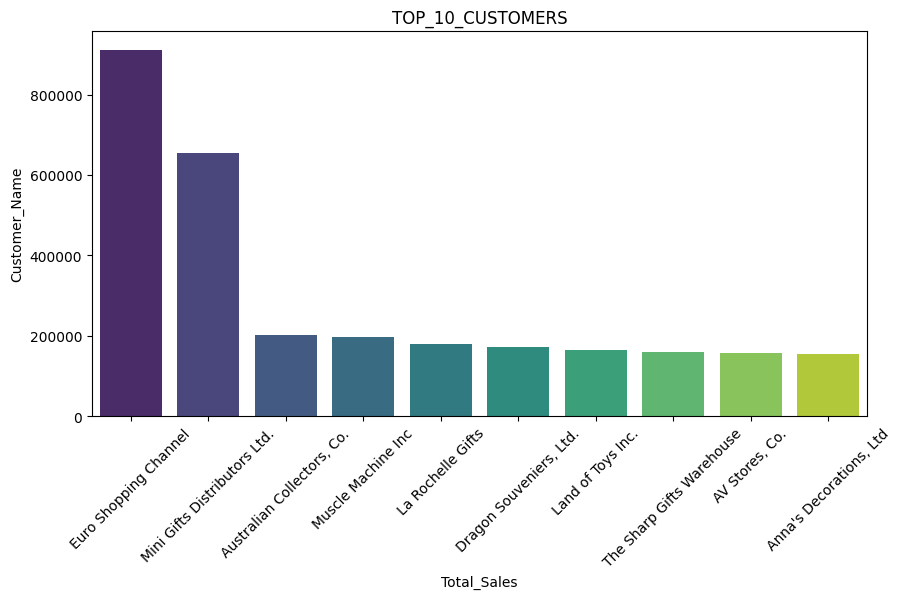

CUSTOMERNAME
Euro Shopping Channel           912294.11
Mini Gifts Distributors Ltd.    654858.06
Australian Collectors, Co.      200995.41
Muscle Machine Inc              197736.94
La Rochelle Gifts               180124.90
Dragon Souveniers, Ltd.         172989.68
Land of Toys Inc.               164069.44
The Sharp Gifts Warehouse       160010.27
AV Stores, Co.                  157807.81
Anna's Decorations, Ltd         153996.13
Name: SALES, dtype: float64

In [74]:
plt.figure(figsize=(10,5))
sns.barplot(x=TOP_ten_customers.index,y=TOP_ten_customers.values,palette="viridis")
plt.title("TOP_10_CUSTOMERS")
plt.xticks(rotation=45)
plt.xlabel("Total_Sales")
plt.ylabel("Customer_Name")
plt.show()
TOP_ten_customers

Insights>>> Euro Shopping Channel generates the highest total sales among all customers, contributing significantly more revenue than other customers. Mini Gifts Distributors Ltd is the second largest customer in terms of sales. The remaining top customers contribute relatively similar sales amounts, indicating that a few key customers account for a large portion of the company’s revenue.

<<FINAL BUSINESS INSIGHTS>>
(1) Classic cars generate the highest revenue among all the product lines.
(2) The USA contributes the largest shares of company sales.
(3) Most transactions fall under small and medium deal size.
(4) Sales show a seasonal trend with peak performance in november.
(5) A small group of customers contributes a significant portion of revenue , with Ero shopping channel being the highest revenue-generating customer.
(6) Quantity Ordered shpws a postive relationship with Sales,indicating that larger order quantites increase revenue.
